In [1]:
from ioMicro import *
import pickle
psf = pickle.load(open(r'C:\Scripts\NMERFISH\psfs\dic_psfff_scope6_60X_cy5_300pix.pkl','rb'))

In [17]:
save_folder=r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_HMERFISH_AnalysisGFP'
ifov = 30
fov = 'Conv_zscan1_'+str(ifov).zfill(3)
#save_folder =r'\\merfish19\merfish19\20240422_R136BICAN2kgene\MERFISHPlate3_4\AnalysisBB_P34_bkremove'
#save_folder =r'R:\Roy\2000gnMERFISH_DCBB_5_9_2024\MERFISH_AnalysisP5P6'
save_fl_ref = r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_QMERFISH_Analysis\scores_ref.pkl'
dec = decoder_simple(save_folder,fov,set_='')
dec.ncols = 1
dec.load_decoded()
dec.dist_best=np.load(dec.decoded_fl)['dist_best']

Loaded decoded: -3.3552112579345703


In [18]:
code =dec.XH_pruned[:,:,-1]
isgood = np.all(code[:,-2:]==[48,49],axis=-1)
isgood2 = np.sum(np.isnan(code),axis=-1)<=1
isgood&=isgood2
dec.XH_pruned = dec.XH_pruned[isgood]
dec.dist_best = dec.dist_best[isgood]
dec.icodesN = dec.icodesN[isgood] 

In [19]:
def get_score_per_color_single(dec,include_dbits=False):
    H = np.nanmedian(dec.XH_pruned[...,-3],axis=1)
    #D = dec.XH_pruned[...,:3]-np.nanmean(dec.XH_pruned[...,:3],axis=1)[:,np.newaxis]
    #D = np.nanmean(np.linalg.norm(D,axis=-1),axis=-1)
    n1bits = dec.XH_pruned.shape[1]
    from itertools import combinations
    combs = np.array(list(combinations(np.arange(n1bits),2)))
    X = dec.XH_pruned[:,:,:3]
    D = np.nanmean(np.linalg.norm(X[:,combs][:,:,0]-X[:,combs][:,:,1],axis=-1),axis=1)
    
    if include_dbits:
        db = dec.dist_best
        score = np.array([H,-D,-db]).T
    else:
        score = np.array([H,-D]).T
    #score = np.sort(score,axis=0)
    cols = np.nanmedian(dec.XH_pruned[:,:,-2][:,:4],axis=-1)
    dec.ncols = int(np.max(cols)+1)
    return [np.sort(score[cols==icol],axis=0) for icol in np.arange(dec.ncols)]

In [20]:
scoresRef = get_score_per_color_single(dec,include_dbits=True)
get_score_withRef(dec,scoresRef,plt_val=True,gene=None,iSs = None,th_min=-7.5,include_dbits=True)

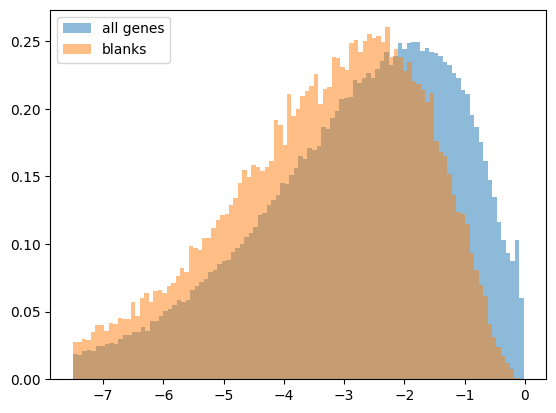

In [21]:
get_score_withRef(dec,scoresRef,plt_val=True,gene=None,iSs = None,th_min=-7.5,include_dbits=True)

['CRE142', 'CRE145', 'CRE157', 'CRE163', 'CRE268', 'CRE298', 'CRE073', 'CRE011', 'CRE250', 'CRE038', 'CRE055', 'CRE005', 'CRE136', 'CRE112', 'CRE299', 'CRE274', 'CRE008', 'CRE064', 'CRE158', 'CRE085', 'CRE235', 'CRE205', 'CRE097', 'CRE199', 'CRE187', 'CRE034', 'CRE196', 'CRE224', 'CRE113', 'CRE036']


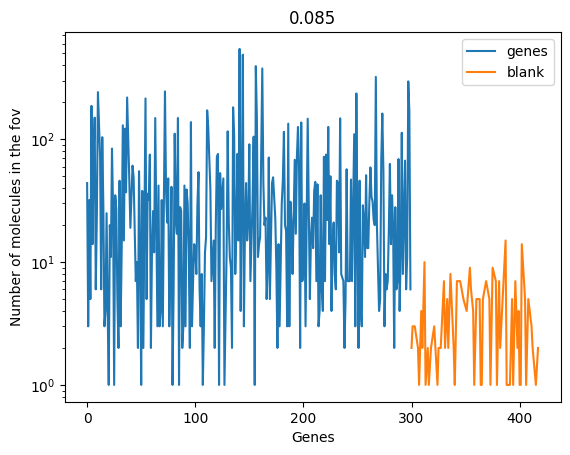

In [22]:
dec.th=-0.5
plot_statistics(dec)

In [10]:
np.unique(dec.icodesN[dec.scoreA>-0.5],return_counts=True)

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  39,  40,
         42,  43,  45,  46,  47,  48,  49,  50,  51,  52,  54,  55,  56,
         57,  58,  59,  60,  61,  62,  63,  65,  66,  67,  68,  69,  70,
         71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
         84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,
         97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
        110, 111, 112, 114, 115, 117, 118, 119, 120, 121, 122, 123, 124,
        126, 127, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
        140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 153,
        154, 155, 156, 157, 158, 159, 160, 162, 163, 164, 165, 166, 167,
        168, 169, 171, 172, 174, 175, 176, 177, 178, 179, 180, 181, 182,
        183, 184, 185, 186, 187, 188, 189, 190, 192

In [23]:
#dec.gns_names

In [11]:
plot_multigenes(dec,
    genes=['CRE142', 'CRE145', 'CRE157', 'CRE163', 'CRE268', 'CRE298'],
    colors=['r', 'g', 'b', 'm', 'c', 'y', 'w'],
    smin=3,
    smax=10,
    viewer=None,
    drift=[0, 0, 0],
    resc=[1, 1, 1],
)

Viewer(camera=Camera(center=(0.0, 1496.1721170743308, 1517.789166132609), zoom=0.2619825440892211, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True), cursor=Cursor(position=(18.606566268205643, 1.0, 0.0), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=3, ndisplay=2, last_used=0, range=((-0.3934337317943573, 39.21032524108887, 1.0), (12.776335875193277, 2969.269775390625, 1.0), (32.405463536580406, 3000.8194173177085, 1.0)), current_step=(19, 1466, 1480), order=(0, 1, 2), axis_labels=('0', '1', '2')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Points layer 'CRE142' at 0x110f9291060>, <Points layer 'CRE145' at 0x110fb8b60e0>, <Points layer 'CRE157' at 0x110f6deef80>, <Points layer 'CRE163' at 0x110f9290f40>, <Points layer 'CRE268' at 0x11102908f10>, <Points layer 'CRE298' at 0x11102a0f730>], help='use <5> for transform, use <2> for add points, use <3> for select points', status='Ready', tooltip=Tooltip(visib

In [24]:
drifts,flds,fov_,fl_ref = np.load(dec.drift_fl,allow_pickle=True)

In [25]:
import dask.array as da
ims = []
for ifld,fld in enumerate(flds):
    im = read_im(fld+os.sep+fov_)[[0,1,2,-1]]
    drft = np.round(drifts[ifld][0]).astype(int)
    im_ = da.roll(im,drft,axis=[-3,-2,-1])
    ims.append(im_[np.newaxis])
ims = da.concatenate(ims)

In [26]:
import napari
napari.view_image(ims)

Viewer(camera=Camera(center=(0.0, 1499.5, 1499.5), zoom=0.23893979899497483, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True), cursor=Cursor(position=(8.0, 1.0, 19.0, 0.0, 0.0), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=5, ndisplay=2, last_used=0, range=((0.0, 17.0, 1.0), (0.0, 4.0, 1.0), (0.0, 40.0, 1.0), (0.0, 3000.0, 1.0), (0.0, 3000.0, 1.0)), current_step=(8, 1, 19, 1499, 1499), order=(0, 1, 2, 3, 4), axis_labels=('0', '1', '2', '3', '4')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'ims' at 0x1106f21e260>], help='use <2> for transform', status='Ready', tooltip=Tooltip(visible=False, text=''), theme='dark', title='napari', mouse_over_canvas=False, mouse_move_callbacks=[], mouse_drag_callbacks=[], mouse_double_click_callbacks=[], mouse_wheel_callbacks=[<function dims_scroll at 0x0000011074317A30>], _persisted_mouse_event={}, _mouse_drag_gen={}, _mouse_wheel_gen={}, keymap={})

Loaded decoded: -5.5848915576934814
Molecules size: (3441158, 6, 10)
Covering reaoduts: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. nan]


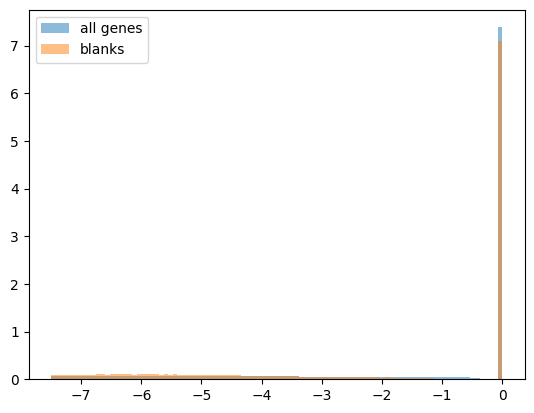

In [85]:


print("Molecules size:",dec.XH_pruned.shape)
print("Covering reaoduts:",np.unique(dec.XH_pruned[:,:,-1]))

scoresRef = get_score_per_color(dec,include_dbits=True)#
#scoresRef = np.load(save_fl_ref,allow_pickle=True)
plt.style.use('default')
get_score_withRef(dec,scoresRef,plt_val=True,gene=None,iSs = None,th_min=-7.5,include_dbits=True)
#dec.th=-1
#plot_statistics(dec)

In [63]:
fl = r'C:\Scripts\NMERFISH\codebooks\codebookCRE300_schizo.csv'
fl_new = r'C:\Scripts\NMERFISH\codebooks\codebookCRE300_schizo_GFP.csv'
fid = open(fl_new,'w')
for ln in open(fl,'r'):
    fid.write(ln.replace(ln[-1],r',1,1'+ln[-1]))
fid.close()

In [72]:
lib_fl = r'C:\Scripts\NMERFISH\codebooks\codebookCRE300_schizo_GFP.csv'
dec.load_library(lib_fl,nblanks=-1)

dec.ncols = 3
get_intersV2(dec,nmin_bits=3,dinstance_th=2,enforce_color=False,enforce_set=None,redo=False)
get_icodesV3(dec,nmin_bits=3,iH=-3)

Calculating lengths of clusters...
Unfolding indexes...
Saving to file: \\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_HMERFISH_AnalysisGFP\resNew_Conv_zscan1_030--.npz
Calculating indexes within cluster...
Calculating index of molecule...
Calculating index of first molecule...
Total time unfolded molecules: 7.2423319816589355
Computing score...
Total time computing score: 0.22929739952087402
Computing sorting...
Total time sorting molecules by score: 10.313358783721924
Finding best bits per molecules...
Finding best code...


100%|█████████████████████████████████████████████████████████████████████| 870/870 [00:01<00:00, 449.04it/s]


Total time best bits per molecule: 98.46713042259216


In [71]:
dec.XH = dec.XH[dec.XH[:,-1]<50]

In [64]:
save_folder=r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_HMERFISH_AnalysisGFP'
ifov = 30
fov = 'Conv_zscan1_'+str(ifov).zfill(3)
set_ = ''
dec = decoder_simple(save_folder,fov=fov,set_=set_)
dec.get_XH(fov,set_,ncols=3,nbits=50,th_h=3600,tag_keep='MER')#number of colors match 
dec.XH = dec.XH[dec.XH[:,-4]>0.25] ### keep the spots that are correlated with the expected PSF for 60X


  0%|                                                                                 | 0/17 [00:00<?, ?it/s]

(227964, 8)
(237979, 8)


  6%|████▎                                                                    | 1/17 [00:00<00:10,  1.53it/s]

(123876, 8)
(290064, 8)
(262027, 8)
(140305, 8)


 12%|████████▌                                                                | 2/17 [00:01<00:09,  1.66it/s]

...

 94%|███████████████████████████████████████████████████████████████████▊    | 16/17 [00:08<00:00,  1.95it/s]

(162925, 8)
(103253, 8)
(919846, 8)
(712940, 8)


100%|████████████████████████████████████████████████████████████████████████| 17/17 [00:09<00:00,  1.81it/s]

(46193, 8)


NameError: name 'lib_fl' is not defined

Loaded decoded: -7.13146710395813
Molecules size: (8675502, 4, 10)
Covering reaoduts: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53.
 54. 55. 56. 57. 58. 59. nan]


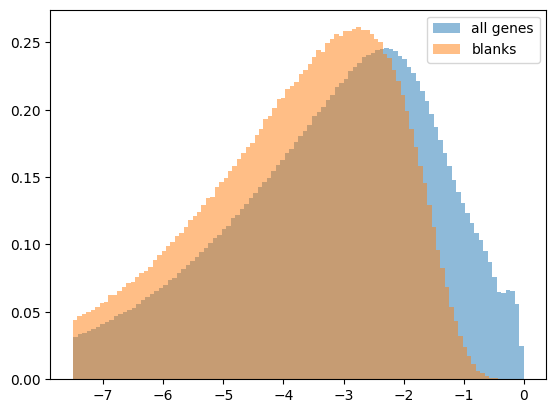

In [12]:
save_folder=r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_QMERFISH_Analysis'
ifov = 30
fov = 'Conv_zscan1_'+str(ifov).zfill(3)
#save_folder =r'\\merfish19\merfish19\20240422_R136BICAN2kgene\MERFISHPlate3_4\AnalysisBB_P34_bkremove'
#save_folder =r'R:\Roy\2000gnMERFISH_DCBB_5_9_2024\MERFISH_AnalysisP5P6'
save_fl_ref = r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_QMERFISH_Analysis\scores_ref.pkl'
dec = decoder_simple(save_folder,fov,set_='')
dec.ncols = 3
dec.load_decoded()
dec.dist_best=np.load(dec.decoded_fl)['dist_best']

print("Molecules size:",dec.XH_pruned.shape)
print("Covering reaoduts:",np.unique(dec.XH_pruned[:,:,-1]))

scoresRef = get_score_per_color(dec,include_dbits=True)#
#scoresRef = np.load(save_fl_ref,allow_pickle=True)
plt.style.use('default')
get_score_withRef(dec,scoresRef,plt_val=True,gene=None,iSs = None,th_min=-7.5,include_dbits=True)
#dec.th=-1
#plot_statistics(dec)

['NEFL', 'MT-CO1', 'NEFM', 'TUBA1A', 'IDS', 'UCHL1', 'DCX', 'NNAT', 'NLK', 'EEF2', 'ATP9A', 'BASP1', 'CNR1', 'PPP2R2B', 'STMN2', 'SLC17A6', 'CNTN1', 'PDE4DIP', 'YWHAB', 'APP', 'CADM2', 'SNAP91', 'SCN2A', 'NTM', 'REEP1', 'ONECUT3', 'WASHC2A', 'TNC', 'IGFBPL1', 'LMO4']


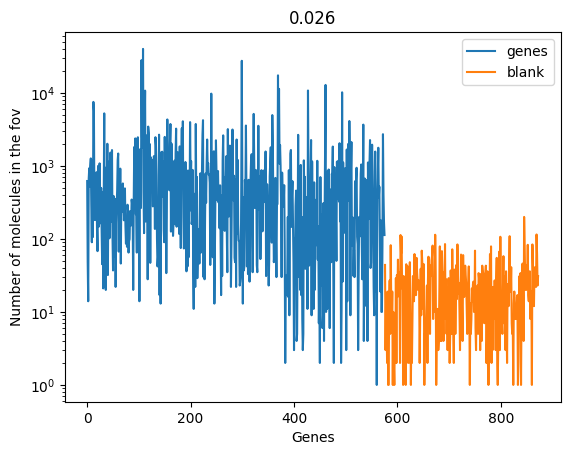

In [13]:
dec.th=-1
plot_statistics(dec)

In [14]:
XH_pruned = dec.XH_pruned[dec.scoreA>dec.th]

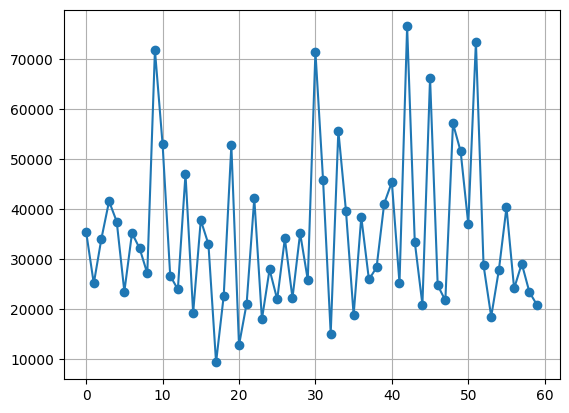

In [15]:
bits,ncts = np.unique(XH_pruned[:,:,-1],return_counts=True)
plt.plot(bits,ncts,'o-')
plt.grid(True)

In [16]:
plot_multigenes(dec,
    genes=['TNC', 'LMO4','DCX'],
    colors=['r', 'g', 'w', 'm', 'c', 'y', 'b'],
    smin=3,
    smax=10,
    viewer=None,
    drift=[0, 0, 0],
    resc=[1, 1, 1],
)

Viewer(camera=Camera(center=(0.0, 1499.0685925483704, 1509.3462189833324), zoom=0.16079886770825338, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True), cursor=Cursor(position=(18.98303866169105, 1.0, 0.0), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=3, ndisplay=2, last_used=0, range=((-0.016961338308950264, 40.23690668741862, 1.0), (0.6703141927719116, 2986.7662760416665, 1.0), (15.101649761199951, 2999.8938802083335, 1.0)), current_step=(19, 1471, 1489), order=(0, 1, 2), axis_labels=('0', '1', '2')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Points layer 'TNC' at 0x1106cc64e80>, <Points layer 'LMO4' at 0x1106ca53eb0>, <Points layer 'DCX' at 0x1106cc65d20>], help='use <5> for transform, use <2> for add points, use <3> for select points', status='Ready', tooltip=Tooltip(visible=False, text=''), theme='dark', title='napari', mouse_over_canvas=False, mouse_move_callbacks=[], mouse_drag_callbacks=[], mouse

In [48]:
print(list(np.sort([e for e in dec.gns_names if 'blank' not in e])))

['ABCB1', 'ABHD17A', 'ACHE', 'ADAM11', 'ADAMTSL1', 'ADAMTSL5', 'ADARB2', 'ADAT3', 'ADCK5', 'ADCY2', 'AGAP6', 'AHSP', 'AIF1', 'AIF1L', 'ALAS2', 'ALCAM', 'ALDH1A1', 'ALDH1B1', 'ALDOC', 'ALK', 'ANKRD18A', 'ANKRD24', 'ANO5', 'ANTXR2', 'APBA3', 'APC2', 'APP', 'AQP4', 'ARHGAP29', 'ARHGAP39', 'ARPP21', 'ASPM', 'ASTN2', 'ATCAY', 'ATP2B1', 'ATP5F1D', 'ATP8B3', 'ATP9A', 'AURKA', 'BASP1', 'BCAN', 'BCL11B', 'BHLHE22', 'BLCAP', 'BOP1', 'BRINP3', 'BTBD2', 'BTG1', 'C10orf53', 'C11orf88', 'C11orf96', 'C19orf25', 'C1QB', 'C1QC', 'C1orf53', 'C1orf61', 'C1orf64', 'C20orf194', 'C5orf47', 'C8orf82', 'C9orf24', 'CACNG4', 'CADM2', 'CALB1', 'CALD1', 'CAPN6', 'CAPS2', 'CBARP', 'CCDC179', 'CCK', 'CCL3L3', 'CCL4', 'CCNA2', 'CCNB1', 'CCNB2', 'CCNE1', 'CCNE2', 'CCNF', 'CCSER1', 'CD22', 'CD9', 'CDC20', 'CDH18', 'CDH3', 'CDK1', 'CDKN3', 'CEP19', 'CFAP126', 'CFAP299', 'CFAP43', 'CFAP45', 'CHAT', 'CHGB', 'CHRM3', 'CHRNA3', 'CIRBP', 'CLDN5', 'CLIP4', 'CLSTN2', 'CLU', 'CNN2', 'CNR1', 'CNTN1', 'COL11A1', 'COL18A1', 'COL1

In [2]:
im = np.array(read_im(r'E:\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024\HpolyT\Conv_zscan1_000.zarr'),dtype=np.float32)

In [37]:
import dask.array as da
da.from_zarr(r'O:\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024\Q17_MER_17\050\data')

ArrayNotFoundError: array not found at path %r' ''

In [35]:
read_im()

ArrayNotFoundError: array not found at path %r' ''

In [22]:
im_ = im[-1]**2

In [20]:
imd = full_deconv(
    im_,
    s_=300,
    pad=100,
    psf=psf,
    parameters={'method': 'wiener', 'beta': 0.001, 'niter': 50},
    gpu=True,
    force=True,
)

100%|██████████████████████████████████████████████████████████████████████| 100/100 [00:11<00:00,  8.96it/s]


In [23]:
imddapi = full_deconv(
    im_,
    s_=300,
    pad=100,
    psf=psf,
    parameters={'method': 'wiener', 'beta': 0.001, 'niter': 50},
    gpu=True,
    force=True,
)

100%|██████████████████████████████████████████████████████████████████████| 100/100 [00:11<00:00,  8.80it/s]


In [17]:
import napari

In [26]:
V = napari.view_image(imd[:,::1,::1],blending='Additive',colormap='green')
V.add_image(imddapi[:,::1,::1],blending='Additive',colormap='bop blue')

<Image layer 'Image [1]' at 0x21efdae8520>